In [84]:
import skeleton_codes as skeleton
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [85]:
img_path = "./test_image.jpg"

img_gray = skeleton.load_gray(str(img_path))
print(f"image shape: {img_gray.shape}")


image shape: (275, 489)


In [86]:
levels   = 5
gains    = [0.35, 0.50, 0.75, 0.95, 1.00]

G = skeleton.build_gaussian_pyr(img_gray, levels)
Ls, Gtop = skeleton.build_laplacian_pyr(G)

Setting 1 - No noise MSE: 1.784452824771065e-19


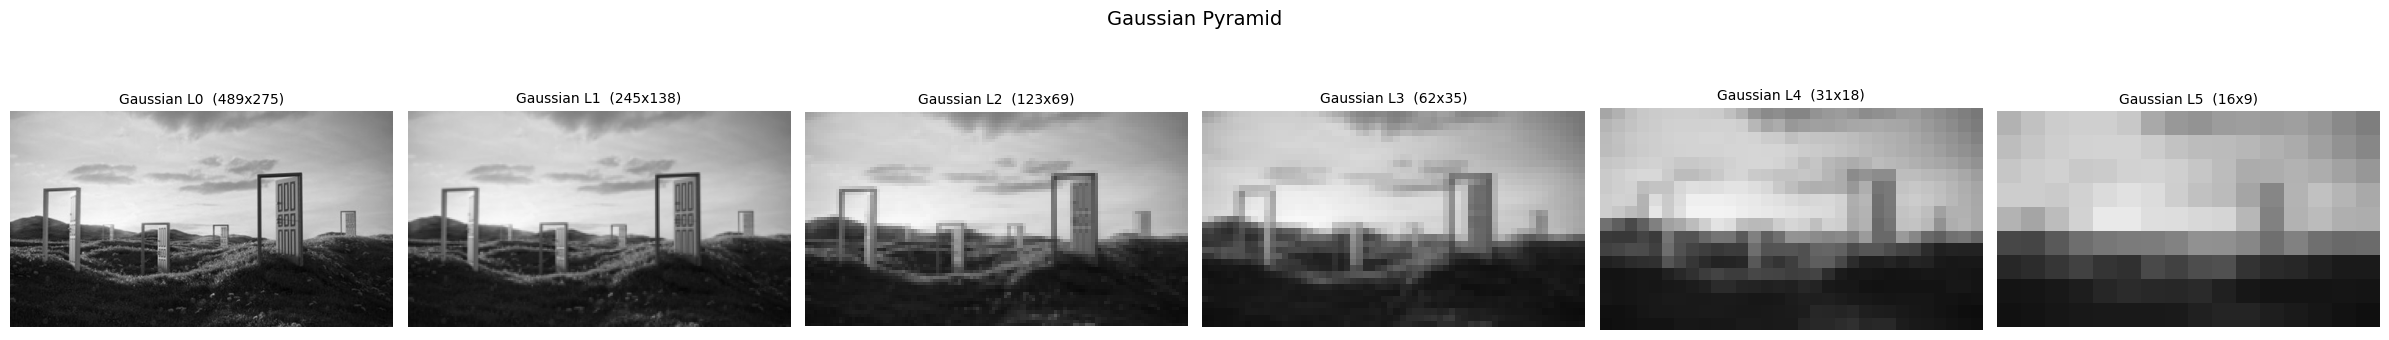

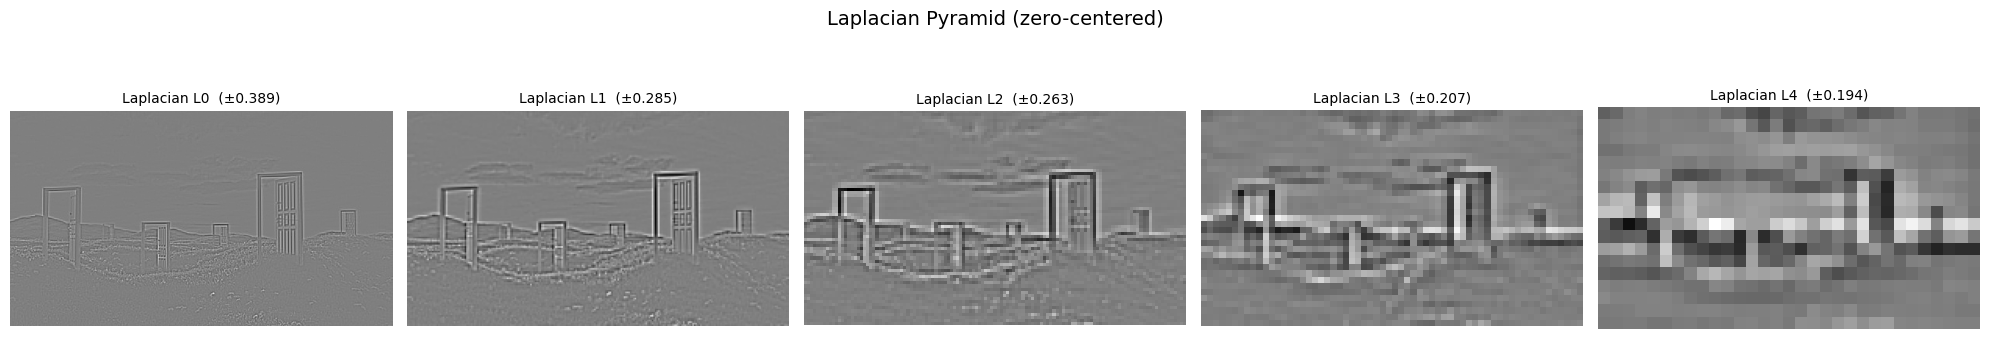

In [87]:
# import cv2

rec = skeleton.reconstruct_from_lap(Ls, Gtop)
mse = np.mean((rec - skeleton.to_float01(img_gray))**2)
print(f"Setting 1 - No noise MSE: {mse}")  # expect MSE ≤ 1e-4

skeleton.visualize_pyramids(G, Ls, G_top=Gtop, recon=rec)

# I tried to use openCV to save images, i am not using openCV for other parts only to save images (as mentioned in the document)
# cv2.imsave doesn't give same image as visualize_pyramids for laplacian images so i will use plt.imsave
# same setting with visualize_pyramids in skeleton code
for i, g in enumerate(G):
    plt.imsave(f'filtered_images/G{i}_setting1.png', g, cmap='gray', vmin=0, vmax=1)
for i, L in enumerate(Ls):
    a = np.max(np.abs(L)) + 1e-8
    plt.imsave(f'filtered_images/L{i}_setting1.png', L, cmap='gray', vmin=-a, vmax=a)

sigma=0.01 (Setting 1)
PSNR(Noisy Image): 39.97 dB
PSNR(Denoised Image): 29.86 dB


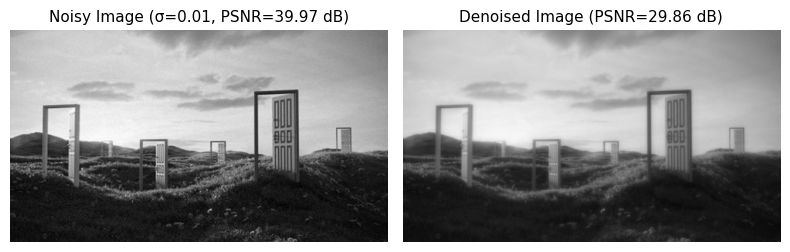

sigma=0.05 (Setting 1)
PSNR(Noisy Image): 26.13 dB
PSNR(Denoised Image): 28.56 dB


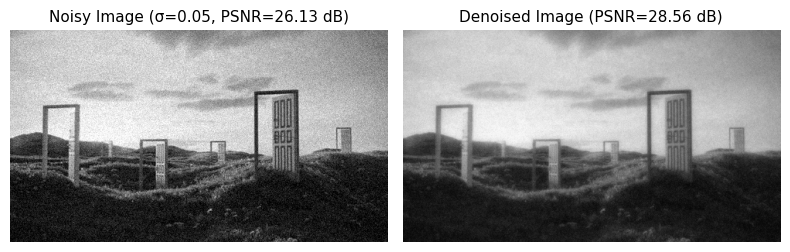

sigma=0.1 (Setting 1)
PSNR(Noisy Image): 20.51 dB
PSNR(Denoised Image): 26.11 dB


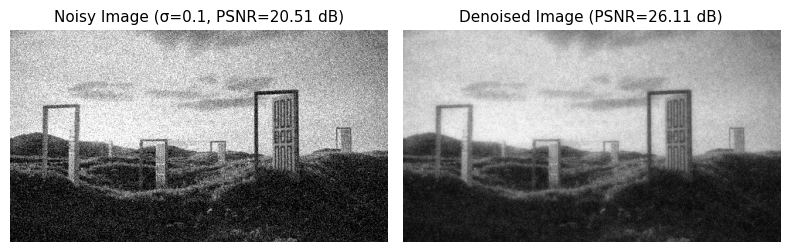

In [88]:
sigmas = [0.01, 0.05, 0.1]
for sigma in sigmas:
    print(f"sigma={sigma} (Setting 1)")
    noisy, sigma_val = skeleton.add_gaussian_noise(img_gray, sigma=sigma, seed=42)
    denoised = skeleton.lap_pyr_filter(noisy, gains=gains, levels=levels)
    
    # PSNR
    psnr_noisy = skeleton.psnr(img_gray, noisy)
    psnr_denoised = skeleton.psnr(img_gray, denoised)
    print(f"PSNR(Noisy Image): {psnr_noisy:.2f} dB")
    print(f"PSNR(Denoised Image): {psnr_denoised:.2f} dB")

    # same setting with visualize_pyramids in skeleton code
    skeleton.show_side_by_side(
        [noisy, denoised],
        titles=[f"Noisy Image (σ={sigma}, PSNR={psnr_noisy:.2f} dB)",
                f"Denoised Image (PSNR={psnr_denoised:.2f} dB)"]
    )
    plt.imsave(f'filtered_images/noisy_sigma_{sigma}_setting1.png', noisy, cmap='gray', vmin=0, vmax=1)
    plt.imsave(f'filtered_images/denoised_sigma_{sigma}_setting1.png', denoised, cmap='gray', vmin=0, vmax=1)



Setting 2 - No noise MSE: 1.784452824771065e-19


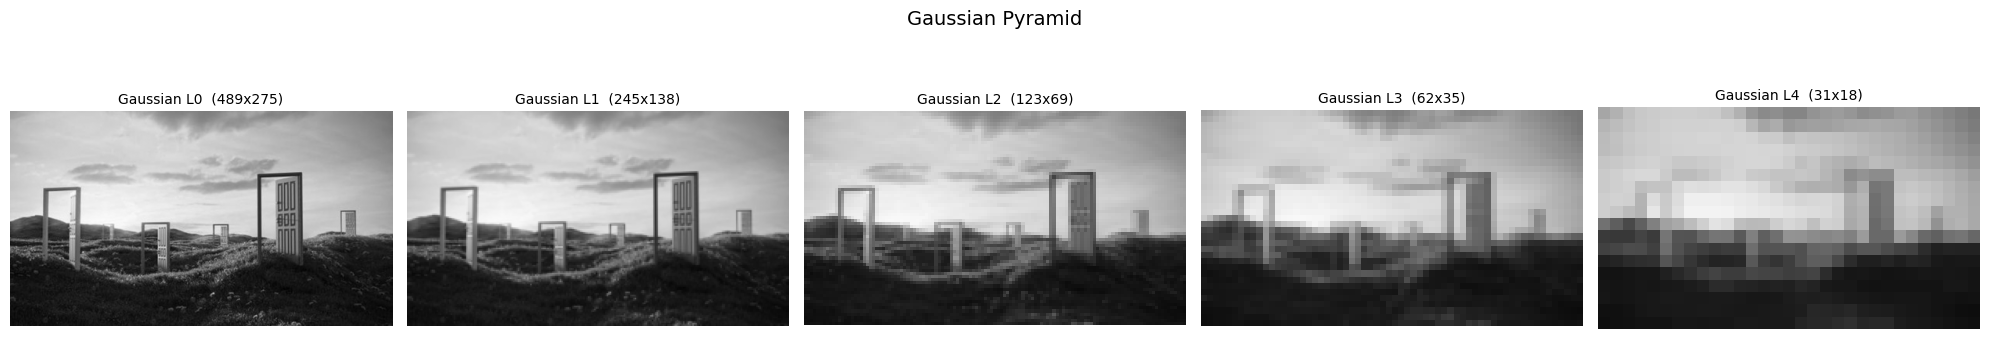

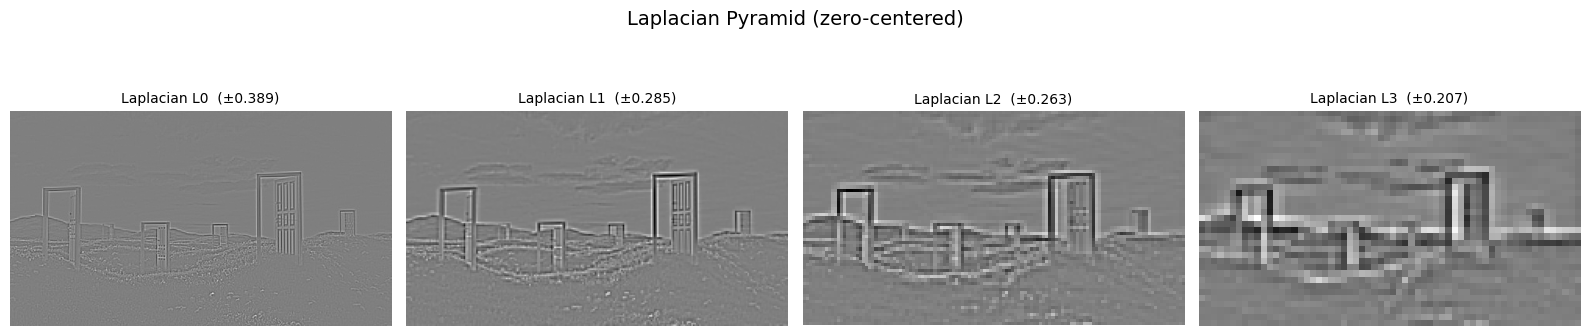

In [89]:
levels = 4
gains = [0.60, 0.75, 0.90, 1.00]

G = skeleton.build_gaussian_pyr(img_gray, levels)
Ls, Gtop = skeleton.build_laplacian_pyr(G)

rec = skeleton.reconstruct_from_lap(Ls, Gtop)
mse = np.mean((rec - skeleton.to_float01(img_gray))**2)
print(f"\nSetting 2 - No noise MSE: {mse}")  # expect MSE ≤ 1e-4

# same setting with visualize_pyramids in skeleton code
skeleton.visualize_pyramids(G, Ls, G_top=Gtop, recon=rec)

for i, g in enumerate(G):
    plt.imsave(f'filtered_images/G{i}_setting2.png', g, cmap='gray', vmin=0, vmax=1)
for i, L in enumerate(Ls):
    a = np.max(np.abs(L)) + 1e-8
    plt.imsave(f'filtered_images/L{i}_setting2.png', L, cmap='gray', vmin=-a, vmax=a)

sigma=0.01 (Setting 2)
PSNR(Noisy Image): 39.97 dB
PSNR(Denoised Image): 34.72 dB


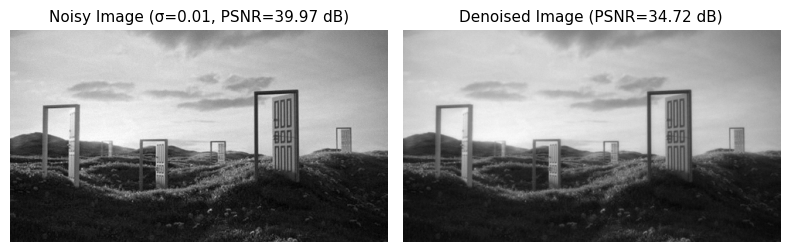

sigma=0.05 (Setting 2)
PSNR(Noisy Image): 26.13 dB
PSNR(Denoised Image): 28.96 dB


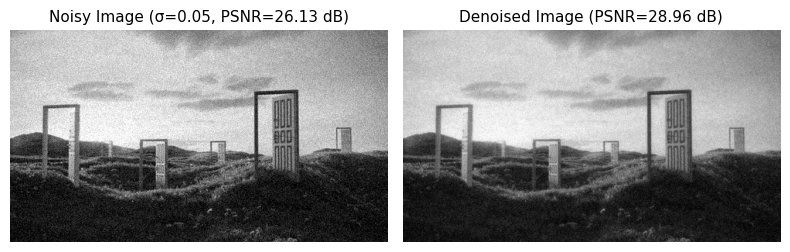

sigma=0.1 (Setting 2)
PSNR(Noisy Image): 20.51 dB
PSNR(Denoised Image): 24.11 dB


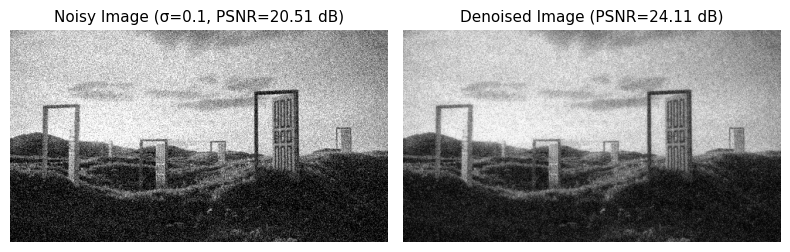

In [90]:
for sigma in sigmas:
    print(f"sigma={sigma} (Setting 2)")
    noisy, sigma_val = skeleton.add_gaussian_noise(img_gray, sigma=sigma, seed=42)
    denoised = skeleton.lap_pyr_filter(noisy, gains=gains, levels=levels)

    # PSNR
    psnr_noisy = skeleton.psnr(img_gray, noisy)
    psnr_denoised = skeleton.psnr(img_gray, denoised)
    print(f"PSNR(Noisy Image): {psnr_noisy:.2f} dB")
    print(f"PSNR(Denoised Image): {psnr_denoised:.2f} dB")

    # same setting with visualize_pyramids in skeleton code
    skeleton.show_side_by_side(
        [noisy, denoised],
        titles=[f"Noisy Image (σ={sigma}, PSNR={psnr_noisy:.2f} dB)",
                f"Denoised Image (PSNR={psnr_denoised:.2f} dB)"]
    )
    plt.imsave(f'filtered_images/noisy_sigma_{sigma}_setting2.png', noisy, cmap='gray', vmin=0, vmax=1)
    plt.imsave(f'filtered_images/denoised_sigma_{sigma}_setting2.png', denoised, cmap='gray', vmin=0, vmax=1)

p=0.01, Salt & Pepper Noise (Setting 1)
PSNR(Noisy Image): 24.44 dB
PSNR(Denoised Image): 27.97 dB


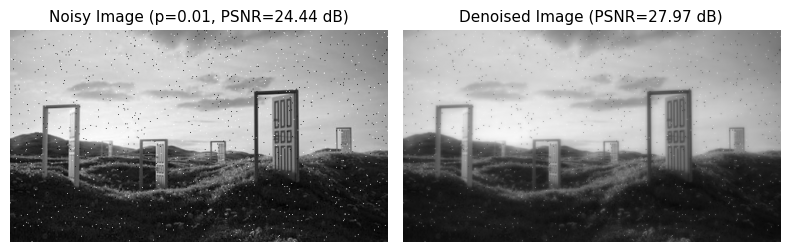

p=0.02, Salt & Pepper Noise (Setting 1)
PSNR(Noisy Image): 21.52 dB
PSNR(Denoised Image): 26.65 dB


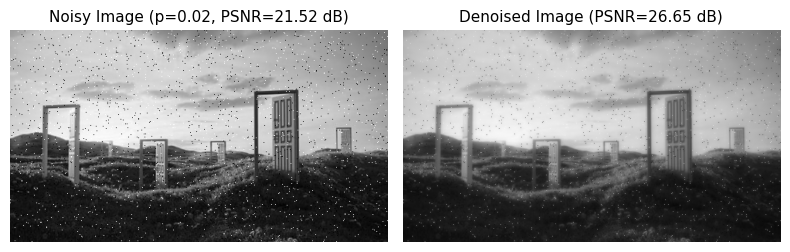

p=0.05, Salt & Pepper Noise (Setting 1)
PSNR(Noisy Image): 17.55 dB
PSNR(Denoised Image): 23.93 dB


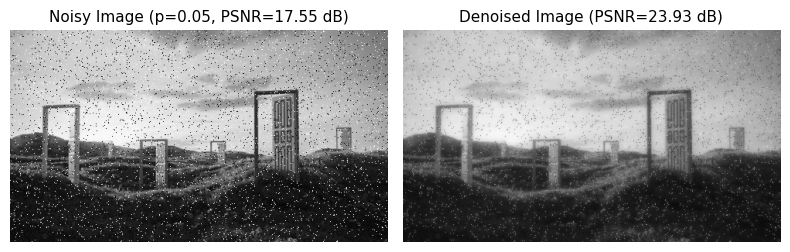

In [91]:
ps = [0.01, 0.02, 0.05]    # probability for Salt & Pepper Noise

levels = 5
gains = [0.35, 0.50, 0.75, 0.95, 1.00]
for p in ps:
    print(f"p={p}, Salt & Pepper Noise (Setting 1)")
    noisy = skeleton.add_salt_pepper(img_gray, p=p, seed=42)
    denoised = skeleton.lap_pyr_filter(noisy, gains=gains, levels=levels)

    # PSNR
    psnr_noisy = skeleton.psnr(img_gray, noisy)
    psnr_denoised = skeleton.psnr(img_gray, denoised)
    print(f"PSNR(Noisy Image): {psnr_noisy:.2f} dB")
    print(f"PSNR(Denoised Image): {psnr_denoised:.2f} dB")

    # same setting with visualize_pyramids in skeleton code
    skeleton.show_side_by_side(
        [noisy, denoised],
        titles=[f"Noisy Image (p={p}, PSNR={psnr_noisy:.2f} dB)",
                f"Denoised Image (PSNR={psnr_denoised:.2f} dB)"]
    )
    plt.imsave(f'filtered_images/noisy_p_{p}_setting1.png', noisy, cmap='gray', vmin=0, vmax=1)
    plt.imsave(f'filtered_images/denoised_p_{p}_setting1.png', denoised, cmap='gray', vmin=0, vmax=1)



p=0.01, Salt & Pepper Noise (Setting 2)
PSNR(Noisy Image): 24.44 dB
PSNR(Denoised Image): 27.59 dB


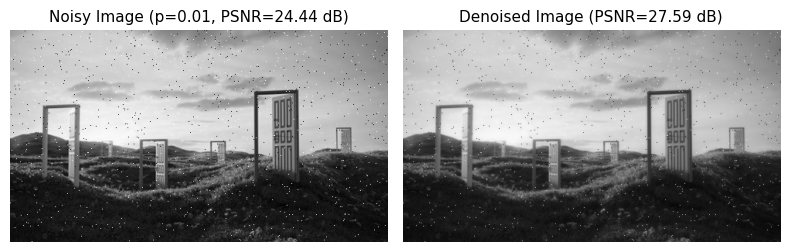

p=0.02, Salt & Pepper Noise (Setting 2)
PSNR(Noisy Image): 21.52 dB
PSNR(Denoised Image): 25.03 dB


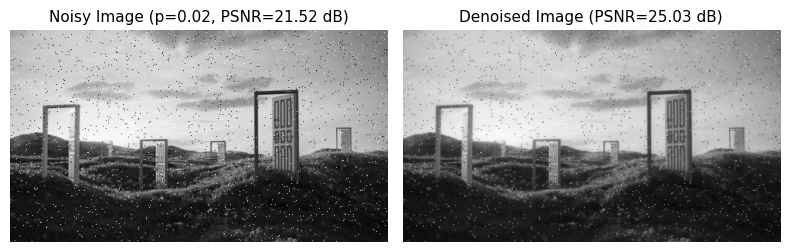

p=0.05, Salt & Pepper Noise (Setting 2)
PSNR(Noisy Image): 17.55 dB
PSNR(Denoised Image): 21.23 dB


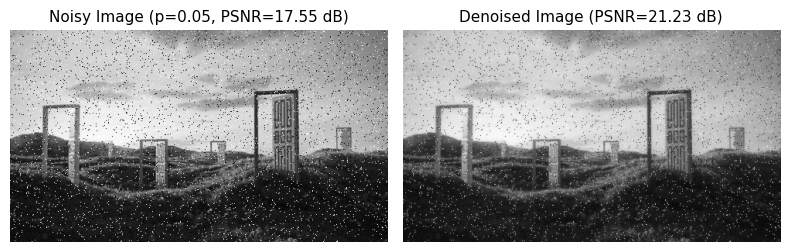

In [92]:
levels = 4
gains = [0.60, 0.75, 0.90, 1.00]
for p in ps:
    print(f"p={p}, Salt & Pepper Noise (Setting 2)")
    noisy = skeleton.add_salt_pepper(img_gray, p=p, seed=42)
    denoised = skeleton.lap_pyr_filter(noisy, gains=gains, levels=levels)

    # PSNR
    psnr_noisy = skeleton.psnr(img_gray, noisy)
    psnr_denoised = skeleton.psnr(img_gray, denoised)
    print(f"PSNR(Noisy Image): {psnr_noisy:.2f} dB")
    print(f"PSNR(Denoised Image): {psnr_denoised:.2f} dB")

    # same setting with visualize_pyramids in skeleton code
    skeleton.show_side_by_side(
        [noisy, denoised],
        titles=[f"Noisy Image (p={p}, PSNR={psnr_noisy:.2f} dB)",
                f"Denoised Image (PSNR={psnr_denoised:.2f} dB)"]
    )
    plt.imsave(f'filtered_images/noisy_p_{p}_setting2.png', noisy, cmap='gray', vmin=0, vmax=1)
    plt.imsave(f'filtered_images/denoised_p_{p}_setting2.png', denoised, cmap='gray', vmin=0, vmax=1)